# **Install Libraries**

In [1]:
!pip install transformers datasets scikit-learn torch

# **Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# **Load Dataset**

In [5]:
df = pd.read_csv('telecom_churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


# **Check Data**

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **Preprocessing**

In [8]:
# Fill missing values
df.fillna('', inplace=True)

# Convert target to numeric (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Convert all features into one text column
df['text'] = df.astype(str).agg(' '.join, axis=1)

df[['text','Churn']].head()

/tmp/ipykernel_2207/88265466.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)


,text,Churn
0,7590-VHVEG Female 0 Yes No 1 No No phone servi...,0
1,5575-GNVDE Male 0 No No 34 Yes No DSL Yes No Y...,0
2,3668-QPYBK Male 0 No No 2 Yes No DSL Yes Yes N...,1
3,7795-CFOCW Male 0 No No 45 No No phone service...,0
4,9237-HQITU Female 0 No No 2 Yes No Fiber optic...,1


# **Train / Validation / Test Split**

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['Churn'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

# **Tokenization**

In [10]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# **Create Dataset Class**

In [11]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)

# **Load BERT Model**

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **Training Arguments**

In [13]:
#!pip install --upgrade transformers

In [14]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# **Metrics Function**

In [15]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [16]:
train_dataset = Dataset(train_encodings, train_labels)

In [17]:
print(type(train_encodings))

<class 'transformers.tokenization_utils_base.BatchEncoding'>


# **Trainer**

In [18]:
#!pip install --upgrade transformers

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# **Train Model**

In [20]:
trainer.train()

Step,Training Loss
500,0.029988
1000,0.000092


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1410, training_loss=0.010684987604089662, metrics={'train_runtime': 193.1977, 'train_samples_per_second': 58.324, 'train_steps_per_second': 7.298, 'total_flos': 318477432517200.0, 'train_loss': 0.010684987604089662, 'epoch': 2.0})

# **Evaluate Model**

In [21]:
preds_output = trainer.predict(test_dataset)

preds = np.argmax(preds_output.predictions, axis=1)
labels = test_labels.values

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
acc = accuracy_score(labels, preds)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [22]:
#results = trainer.evaluate(test_dataset)
#print(results)

# **Confusion Matrix**

In [23]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

cm = confusion_matrix(test_labels, preds)
print(cm)

[[519   0]
 [  0 186]]


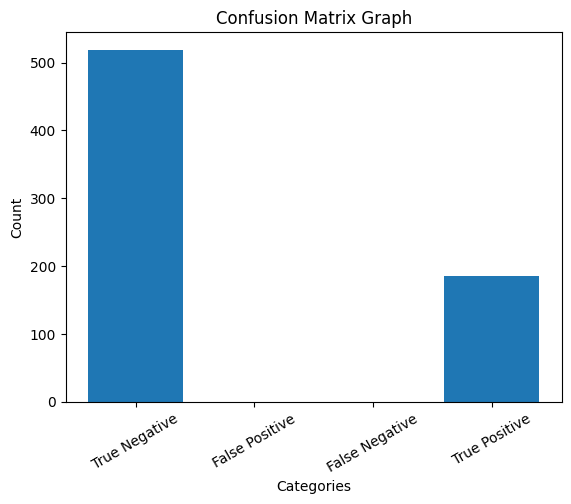

In [24]:
import matplotlib.pyplot as plt

# Confusion matrix values
tn, fp, fn, tp = cm.ravel()

labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
values = [tn, fp, fn, tp]

plt.figure()
plt.bar(labels, values)
plt.xlabel("Categories")
plt.ylabel("Count")
plt.title("Confusion Matrix Graph")
plt.xticks(rotation=30)
plt.show()

# **EXPERIMENT 1 (Freeze BERT)**

In [25]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

for param in model.bert.parameters():
    param.requires_grad = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.584045
1000,0.566467


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1410, training_loss=0.577576690024518, metrics={'train_runtime': 58.44, 'train_samples_per_second': 192.813, 'train_steps_per_second': 24.127, 'total_flos': 318477432517200.0, 'train_loss': 0.577576690024518, 'epoch': 2.0})

# **Evaluate Freeze Model**

In [26]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

freeze_acc = accuracy_score(test_labels, preds)
print("Frozen Model Accuracy:", freeze_acc)

Frozen Model Accuracy: 0.7361702127659574


# **EXPERIMENT 2 (Last 2 Layers)**

In [27]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.064363
1000,0.000761


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1410, training_loss=0.023228071682842064, metrics={'train_runtime': 86.7336, 'train_samples_per_second': 129.915, 'train_steps_per_second': 16.257, 'total_flos': 318477432517200.0, 'train_loss': 0.023228071682842064, 'epoch': 2.0})

# **Evaluate Last 2 Layers**

In [28]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

last2_acc = accuracy_score(test_labels, preds)
print("Last 2 Layers Accuracy:", last2_acc)

Last 2 Layers Accuracy: 1.0


# **Compariosn**

In [29]:
print("Base Model Accuracy:", acc)
print("Frozen Model Accuracy:", freeze_acc)
print("Last 2 Layers Accuracy:", last2_acc)

Base Model Accuracy: 1.0
Frozen Model Accuracy: 0.7361702127659574
Last 2 Layers Accuracy: 1.0


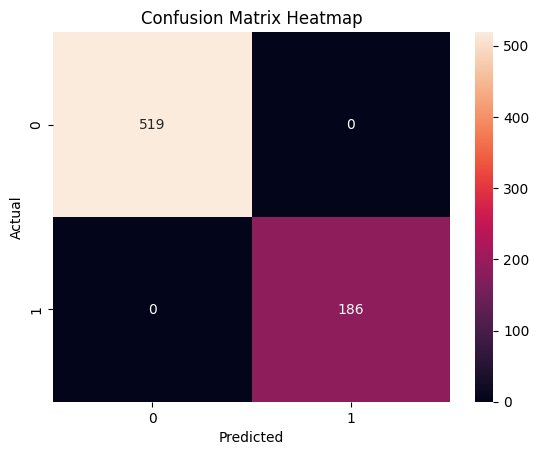

In [30]:
#Acuuracy comparison graph
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# **Experiment (Freeze BERT)**

In [31]:
for param in model.bert.parameters():
    param.requires_grad = False

trainer.train()

Step,Training Loss
500,0.000274
1000,0.000157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1410, training_loss=0.00018929524730283318, metrics={'train_runtime': 71.5397, 'train_samples_per_second': 157.507, 'train_steps_per_second': 19.709, 'total_flos': 318477432517200.0, 'train_loss': 0.00018929524730283318, 'epoch': 2.0})